# PredNet — Within-Dataset Performance
Tests each model checkpoint on its own stimulus type.
Artificial stimuli (Grating, Moving Dots, Sqr Grating, Motion Cloud) share **one** checkpoint
trained on a single combined list. The run cell loads that model once and evaluates it on
the full combined list and optionally on per-stimulus subsets (filtered by filename keyword).
SA-FARI uses its own separate checkpoint and test list as before.
Produces per-model MAE, prediction panels, optical flow and MAE-over-time plots.

In [1]:
import sys, subprocess
for pkg in ['opencv-python', 'imageio[pyav]']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'], check=True)
print('Packages ready.')

Packages ready.


In [2]:
import os, math, glob
import numpy as np
import torch
import torch.nn as nn
from torch.nn import Parameter, functional as F
from torch.nn.modules.utils import _pair
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
# ARTIFICIAL STIMULI
# All four artificial stimulus types were trained together from one combined list,
# so they share a single checkpoint. Point both paths at that combined file.
#
# SUBSETS (optional per-stimulus breakdown)
# If your combined list encodes the stimulus type in the filename
# (e.g. '.../grating_frame_00001.npy'), fill in the keyword dict below.
# Each key becomes a separate entry in the results dict.
# Set SUBSETS = {} to skip the breakdown and evaluate only on the full list.
#
ARTIFICIAL_CONFIG = {
    'weights'  : 'models/best_moving_dots.pth',   # <- single combined checkpoint
    'test_list': 'data/train_all.txt',       # <- single combined test list
    'channels' : (1, 48, 96, 192),
    'greyscale': True,
    # keyword that must appear somewhere in the file path for each subset:
    'subsets': {
        'Moving Dots' : 'moving_dots',
        'Motion Cloud': 'motion_cloud',
    },
}

# SA-FARI — separate model and test list (unchanged)
SAFARI_CONFIG = {
    'label'    : 'SA-FARI',
    'weights'  : 'models/best_safari.pth',
    'test_list': 'data/safari_train_list.txt',
    'channels' : (3, 48, 96, 192),
    'greyscale': False,
}

CHUNK      = 20    # frames per inference chunk — matches training input_len
MAX_FRAMES = 500   # max test frames per experiment (keeps runtime manageable)
OUT_DIR    = 'within_dataset_results'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Results will be saved to {OUT_DIR}/')

Results will be saved to within_dataset_results/


In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=1, dilation=1, groups=1, bias=True):
        super().__init__()
        kernel_size = _pair(kernel_size)
        stride      = _pair(stride)
        padding     = _pair(padding)
        dilation    = _pair(dilation)
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.stride       = stride
        self.padding      = padding
        self.padding_h    = tuple(
            k // 2 for k, s, p, d in zip(kernel_size, stride, padding, dilation))
        self.dilation  = dilation
        self.groups    = groups
        self.weight_ih = Parameter(torch.Tensor(4 * out_channels, in_channels  // groups, *kernel_size))
        self.weight_hh = Parameter(torch.Tensor(4 * out_channels, out_channels // groups, *kernel_size))
        self.weight_ch = Parameter(torch.Tensor(3 * out_channels, out_channels // groups, *kernel_size))
        self.bias_ih   = Parameter(torch.Tensor(4 * out_channels))
        self.bias_hh   = Parameter(torch.Tensor(4 * out_channels))
        self.bias_ch   = Parameter(torch.Tensor(3 * out_channels))
        self.register_buffer('wc_blank', torch.zeros(1, 1, 1, 1))
        self.reset_parameters()

    def reset_parameters(self):
        n = 4 * self.in_channels
        for k in self.kernel_size:
            n *= k
        stdv = 1. / math.sqrt(n)
        for w in [self.weight_ih, self.weight_hh, self.weight_ch,
                  self.bias_ih, self.bias_hh, self.bias_ch]:
            w.data.uniform_(-stdv, stdv)

    def forward(self, input, hx):
        h_0, c_0 = hx
        wx   = F.conv2d(input, self.weight_ih, self.bias_ih,
                        self.stride, self.padding, self.dilation, self.groups)
        wh   = F.conv2d(h_0,   self.weight_hh, self.bias_hh,
                        self.stride, self.padding_h, self.dilation, self.groups)
        wc   = F.conv2d(c_0,   self.weight_ch, self.bias_ch,
                        self.stride, self.padding_h, self.dilation, self.groups)
        wxhc = wx + wh + torch.cat((
            wc[:, :2 * self.out_channels],
            self.wc_blank.expand(wc.size(0), wc.size(1) // 3, wc.size(2), wc.size(3)),
            wc[:, 2 * self.out_channels:]
        ), dim=1)
        i   = torch.sigmoid(wxhc[:, :self.out_channels])
        f   = torch.sigmoid(wxhc[:,  self.out_channels:2 * self.out_channels])
        g   = torch.tanh(   wxhc[:, 2 * self.out_channels:3 * self.out_channels])
        o   = torch.sigmoid(wxhc[:, 3 * self.out_channels:])
        c_1 = f * c_0 + i * g
        h_1 = o * torch.tanh(c_1)
        return h_1, (h_1, c_1)


class SatLU(nn.Module):
    def __init__(self, lower=0, upper=255):
        super().__init__()
        self.lower = lower
        self.upper = upper
    def forward(self, x):
        return F.hardtanh(x, self.lower, self.upper)


class PredNet(nn.Module):
    def __init__(self, R_channels, A_channels, output_mode='prediction'):
        super().__init__()
        self.r_channels  = R_channels
        self.a_channels  = A_channels
        self.n_layers    = len(R_channels)
        self.output_mode = output_mode
        r_channels_above = R_channels[1:] + (0,)
        for l in range(self.n_layers):
            cell = ConvLSTMCell(
                2 * A_channels[l] + r_channels_above[l], R_channels[l], kernel_size=3)
            setattr(self, f'cell{l}', cell)
        for l in range(self.n_layers):
            conv = nn.Sequential(
                nn.Conv2d(R_channels[l], A_channels[l], kernel_size=3, padding=1),
                nn.ReLU(),
            )
            if l == 0:
                conv.add_module('satlu', SatLU())
            setattr(self, f'conv{l}', conv)
        self.maxpool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.upsample = nn.Upsample(scale_factor=2)
        for l in range(self.n_layers - 1):
            update_A = nn.Sequential(
                nn.Conv2d(2 * A_channels[l], A_channels[l + 1], kernel_size=3, padding=1),
                self.maxpool,
            )
            setattr(self, f'update_A{l}', update_A)
        self.reset_parameters()

    def reset_parameters(self):
        for l in range(self.n_layers):
            getattr(self, f'cell{l}').reset_parameters()

    def forward(self, input):
        batch_size, time_steps = input.size(0), input.size(1)
        H, W = input.size(-2), input.size(-1)
        dev  = input.device
        E_seq, R_seq, H_seq = [], [], [None] * self.n_layers
        for l in range(self.n_layers):
            ds = 2 ** l
            E_seq.append(torch.zeros(
                batch_size, 2 * self.a_channels[l], H // ds, W // ds, device=dev))
            R_seq.append(torch.zeros(
                batch_size,     self.r_channels[l], H // ds, W // ds, device=dev))
        total_error, frame_prediction = [], None
        for t in range(time_steps):
            A = input[:, t].float()
            for l in reversed(range(self.n_layers)):
                cell = getattr(self, f'cell{l}')
                hx   = H_seq[l] if H_seq[l] is not None else (R_seq[l], R_seq[l])
                lstm_input = E_seq[l] if l == self.n_layers - 1 \
                             else torch.cat([E_seq[l], self.upsample(R_seq[l + 1])], dim=1)
                R_seq[l], H_seq[l] = cell(lstm_input, hx)
            for l in range(self.n_layers):
                A_hat = getattr(self, f'conv{l}')(R_seq[l])
                if l == 0:
                    frame_prediction = A_hat
                pos      = F.relu(A_hat - A)
                neg      = F.relu(A - A_hat)
                E_seq[l] = torch.cat([pos, neg], dim=1)
                if l < self.n_layers - 1:
                    A = getattr(self, f'update_A{l}')(E_seq[l])
            if self.output_mode == 'error':
                mean_error = torch.cat(
                    [e.flatten(1).mean(1, keepdim=True) for e in E_seq], dim=1)
                total_error.append(mean_error)
        if self.output_mode == 'error':
            return torch.stack(total_error, dim=2)
        return frame_prediction

print('Architecture defined.')

Architecture defined.


In [ ]:
def load_model(weights_path, channels):
    """Load a PredNet checkpoint. Returns model in eval mode."""
    assert os.path.exists(weights_path), f'Weights not found: {weights_path}'
    model      = PredNet(channels, channels, output_mode='prediction')
    checkpoint = torch.load(weights_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing:
        print(f'  Warning — missing keys: {missing}')
    model = model.to(device)
    model.eval()
    return model


def load_npy_sequence(list_path, greyscale, max_frames, keyword=None):
    """Load frames from a list file of .npy paths into a tensor.

    If keyword is given, only paths containing that keyword are loaded
    (useful for extracting a per-stimulus subset from a combined list).
    """
    assert os.path.exists(list_path), f'Test list not found: {list_path}'
    with open(list_path) as f:
        paths = [l.strip() for l in f if l.strip()]
    if keyword:
        paths = [p for p in paths if keyword in p]
        if not paths:
            raise ValueError(
                f"No paths in '{list_path}' contain keyword '{keyword}'. "
                "Check that filenames encode the stimulus type, or set subsets = {}."
            )
    paths = paths[:max_frames]
    frames = []
    for p in paths:
        arr = np.load(p).astype(np.float32) / 255.0
        if arr.ndim == 2:
            arr = arr[np.newaxis]
        if greyscale and arr.shape[0] == 3:
            arr = arr.mean(axis=0, keepdims=True)
        elif not greyscale and arr.shape[0] == 1:
            arr = np.repeat(arr, 3, axis=0)
        frames.append(arr)
    frames = np.stack(frames)                               # (T, C, H, W)
    tensor = torch.from_numpy(frames).unsqueeze(0).to(device)  # (1, T, C, H, W)
    return tensor


def run_inference(model, input_tensor, chunk_size):
    """Run PredNet inference in chunks. Returns (all_preds, all_mae)."""
    T         = input_tensor.shape[1]
    all_preds = []
    all_mae   = []
    with torch.no_grad():
        for start in range(0, T - 1, chunk_size):
            end    = min(start + chunk_size + 1, T)
            chunk  = input_tensor[:, start:end]
            pred   = model(chunk)
            all_preds.append(pred.cpu())
            target = chunk[:, -1].cpu()
            mae    = torch.mean(torch.abs(pred.cpu() - target)).item()
            all_mae.append(mae)
    return all_preds, all_mae


def tensor_to_img(t, greyscale):
    """Convert prediction tensor to HxWx3 uint8 for display."""
    arr = t.squeeze().clamp(0, 1).numpy()
    if greyscale:
        if arr.ndim == 3:
            arr = arr[0]
        arr = (arr * 255).astype(np.uint8)
        return np.stack([arr, arr, arr], axis=2)
    else:
        arr = (arr.transpose(1, 2, 0) * 255).astype(np.uint8)
        return arr


def compute_flow(img_a, img_b):
    """HxWx3 uint8 -> dense optical flow (H, W, 2) via Farneback."""
    gray_a = cv2.cvtColor(img_a, cv2.COLOR_RGB2GRAY)
    gray_b = cv2.cvtColor(img_b, cv2.COLOR_RGB2GRAY)
    return cv2.calcOpticalFlowFarneback(
        gray_a, gray_b, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)


def flow_to_rgb(flow):
    """Dense flow (H, W, 2) -> RGB (H, W, 3) using HSV colour wheel."""
    hsv         = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    mag, ang    = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 1] = 255
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def run_experiment(label, model, input_tensor, greyscale, T):
    """Run inference + produce plots for one experiment. Returns result dict."""
    print(f'  Running inference on {T} frames...')
    all_preds, all_mae = run_inference(model, input_tensor, CHUNK)
    mean_mae = np.mean(all_mae)
    print(f'  Mean MAE: {mean_mae:.4f}')

    sample_idx = list(range(0, len(all_preds), max(1, len(all_preds) // 8)))[:8]
    n_cols     = len(sample_idx)

    # ── Prediction panel ──────────────────────────────────────────────────
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 8))
    fig.suptitle(f'{label} — Ground Truth (top) vs Prediction (bottom)', fontsize=12)
    for col, idx in enumerate(sample_idx):
        frame_idx = min(idx * CHUNK + CHUNK - 1, T - 1)
        gt_img    = tensor_to_img(input_tensor[:, frame_idx].cpu(), greyscale)
        pred_img  = tensor_to_img(all_preds[idx], greyscale)
        axes[0, col].imshow(gt_img)
        axes[0, col].set_title(f'f{frame_idx}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(pred_img)
        axes[1, col].set_title(f'MAE {all_mae[idx]:.3f}', fontsize=8)
        axes[1, col].axis('off')
    plt.tight_layout()
    out = os.path.join(OUT_DIR, f'{label.replace(" ","_")}_predictions.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

    # Optical flow panel
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 8))
    fig.suptitle(f'{label} — Optical Flow: GT (top) vs Prediction (bottom)', fontsize=12)
    for col, idx in enumerate(sample_idx):
        frame_idx = min(idx * CHUNK + CHUNK - 1, T - 1)
        prev_idx  = max(frame_idx - 1, 0)
        gt_prev   = tensor_to_img(input_tensor[:, prev_idx].cpu(), greyscale)
        gt_curr   = tensor_to_img(input_tensor[:, frame_idx].cpu(), greyscale)
        pred_curr = tensor_to_img(all_preds[idx], greyscale)
        flow_gt   = compute_flow(gt_prev, gt_curr)
        flow_pred = compute_flow(gt_prev, pred_curr)
        axes[0, col].imshow(flow_to_rgb(flow_gt))
        axes[0, col].set_title(f'GT f{frame_idx}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(flow_to_rgb(flow_pred))
        axes[1, col].set_title(f'Pred f{frame_idx}', fontsize=8)
        axes[1, col].axis('off')
    plt.tight_layout()
    out = os.path.join(OUT_DIR, f'{label.replace(" ","_")}_flow.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

    # MAE over time ─────
    plt.figure(figsize=(10, 3))
    plt.plot(all_mae, marker='o', markersize=3, label='MAE per chunk')
    plt.axhline(mean_mae, color='r', linestyle='--', label=f'Mean: {mean_mae:.4f}')
    plt.title(f'{label} — Prediction Error Over Test Sequence')
    plt.xlabel('Chunk index')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = os.path.join(OUT_DIR, f'{label.replace(" ","_")}_mae.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

    return {
        'all_preds'    : all_preds,
        'all_mae'      : all_mae,
        'mean_mae'     : mean_mae,
        'input_tensor' : input_tensor,
        'T'            : T,
        'greyscale'    : greyscale,
    }


print('Helpers defined.')

Helpers defined.


In [ ]:
results = {}

# Artificial stim
# One model, one combined list. Evaluated per stimulus type by filtering
# paths using a keyword, or on the full list if subsets = {}.
art = ARTIFICIAL_CONFIG
print('\n' + '='*60)
print('  Artificial Stimuli (combined checkpoint)')
print('='*60)

if not os.path.exists(art['weights']):
    print(f"  SKIP — weights not found: {art['weights']}")
elif not os.path.exists(art['test_list']):
    print(f"  SKIP — test list not found: {art['test_list']}")
else:
    print(f"  Loading {art['weights']}...")
    art_model = load_model(art['weights'], art['channels'])
    print(f"  Parameters: {sum(p.numel() for p in art_model.parameters()):,}")

    subsets = art.get('subsets', {})

    if subsets:
        # Per-stimulus-type evaluation
        for sub_label, keyword in subsets.items():
            print(f'\n  --- {sub_label} (keyword: "{keyword}") ---')
            try:
                tensor = load_npy_sequence(
                    art['test_list'], art['greyscale'], MAX_FRAMES, keyword=keyword)
                T = tensor.shape[1]
                print(f'  Input tensor: {tuple(tensor.shape)}')
                results[sub_label] = run_experiment(
                    sub_label, art_model, tensor, art['greyscale'], T)
                del tensor
            except ValueError as e:
                print(f'  SKIP — {e}')
    else:
        # Full combined list as a single experiment
        print(f"  Loading combined test list: {art['test_list']}...")
        tensor = load_npy_sequence(
            art['test_list'], art['greyscale'], MAX_FRAMES)
        T = tensor.shape[1]
        print(f'  Input tensor: {tuple(tensor.shape)}')
        results['Artificial (All)'] = run_experiment(
            'Artificial (All)', art_model, tensor, art['greyscale'], T)
        del tensor

    del art_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# SA-FARI 
saf = SAFARI_CONFIG
print('\n' + '='*60)
print(f"  {saf['label']}")
print('='*60)

if not os.path.exists(saf['weights']):
    print(f"  SKIP — weights not found: {saf['weights']}")
elif not os.path.exists(saf['test_list']):
    print(f"  SKIP — test list not found: {saf['test_list']}")
else:
    print(f"  Loading {saf['weights']}...")
    saf_model = load_model(saf['weights'], saf['channels'])
    print(f"  Parameters: {sum(p.numel() for p in saf_model.parameters()):,}")
    print(f"  Loading test frames from {saf['test_list']}...")
    tensor = load_npy_sequence(saf['test_list'], saf['greyscale'], MAX_FRAMES)
    T = tensor.shape[1]
    print(f'  Input tensor: {tuple(tensor.shape)}')
    results[saf['label']] = run_experiment(
        saf['label'], saf_model, tensor, saf['greyscale'], T)
    del saf_model, tensor
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nAll experiments complete.')


  Artificial Stimuli (combined checkpoint)
  SKIP — test list not found: data/train_list.txt

  SA-FARI
  Loading models/best_safari.pth...
  Parameters: 8,224,932
  Loading test frames from data/safari_train_list.txt...
  Input tensor: (1, 500, 3, 256, 256)
  Running inference on 500 frames...


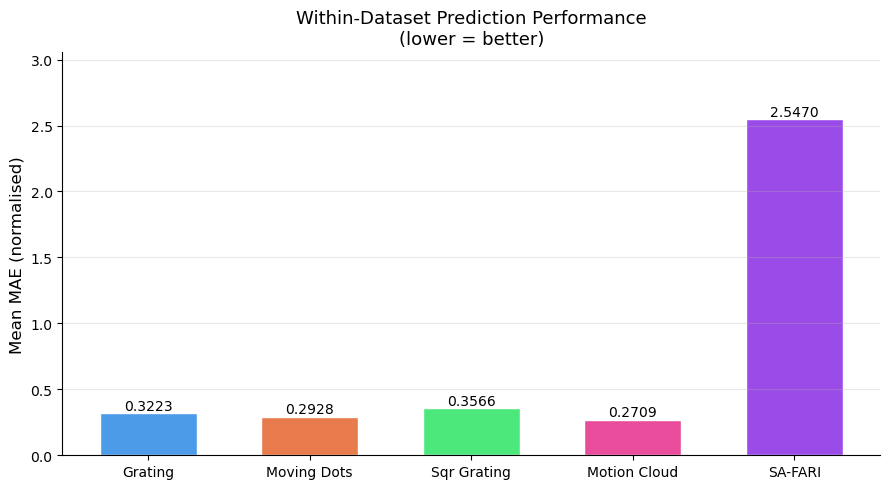

Saved: within_dataset_results\summary_bar_chart.png

Model                   Mean MAE    Chunks
---------------------------------------------
Grating                   0.3223        25
Moving Dots               0.2928        25
Sqr Grating               0.3566        25
Motion Cloud              0.2709        25
SA-FARI                   2.5470        25


In [ ]:
# Summary comparison bar chart 
labels    = list(results.keys())
mean_maes = [results[l]['mean_mae'] for l in labels]

colours = ['#4C9BE8', '#E87B4C', '#4CE87B', '#E84C9B', '#9B4CE8']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, mean_maes, color=colours[:len(labels)], edgecolor='white', width=0.6)

# value labels on bars
for bar, val in zip(bars, mean_maes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean MAE (normalised)', fontsize=12)
ax.set_title('Within-Dataset Prediction Performance\n(lower = better)', fontsize=13)
ax.set_ylim(0, max(mean_maes) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
out = os.path.join(OUT_DIR, 'summary_bar_chart.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')

# print table
print(f'\n{"Model":20s}  {"Mean MAE":>10}  {"Chunks":>8}')
print('-' * 45)
for label in labels:
    r = results[label]
    print(f'{label:20s}  {r["mean_mae"]:>10.4f}  {len(r["all_mae"]):>8}')

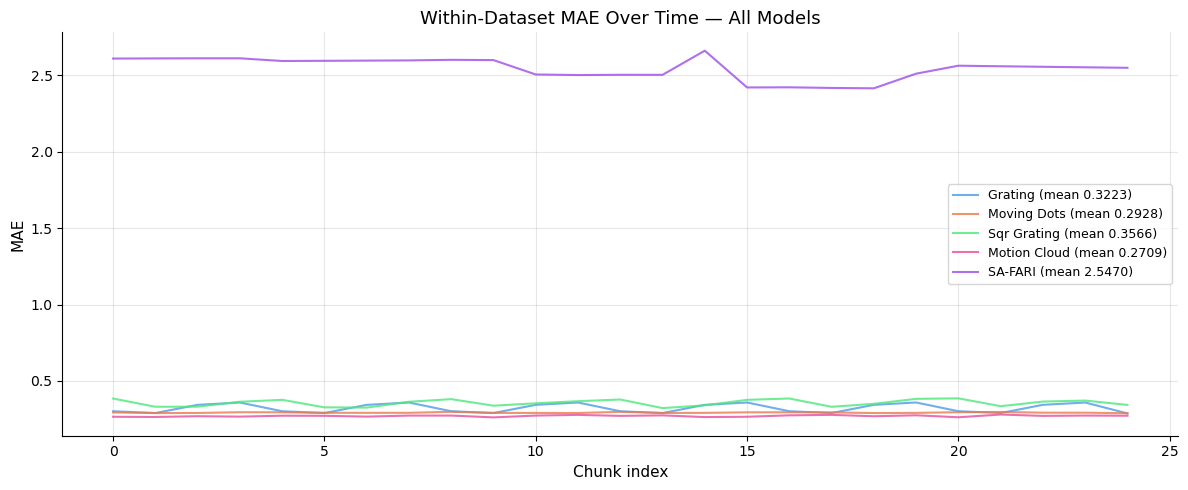

Saved: within_dataset_results\summary_mae_over_time.png


In [ ]:
# ── MAE over time — all models on one plot ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for (label, r), colour in zip(results.items(), colours):
    ax.plot(r['all_mae'], label=f'{label} (mean {r["mean_mae"]:.4f})',
            color=colour, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Chunk index', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Within-Dataset MAE Over Time — All Models', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
out = os.path.join(OUT_DIR, 'summary_mae_over_time.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')